In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

In [7]:
train=pd.read_csv("train.csv")


In [8]:
train

,id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
0,0,21,female,b.sc,7.91,98.8,no,4.9,average,online videos,low,easy,78.300
1,1,18,other,diploma,4.95,94.8,yes,4.7,poor,self-study,medium,moderate,46.700
2,2,20,female,b.sc,4.68,92.6,yes,5.8,poor,coaching,high,moderate,99.000
3,3,19,male,b.sc,2.00,49.5,yes,8.3,average,group study,high,moderate,63.900
4,4,23,male,bca,7.65,86.9,yes,9.6,good,self-study,high,easy,100.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
629995,629995,18,female,b.tech,4.86,70.7,yes,4.1,good,mixed,high,moderate,69.500
629996,629996,21,female,ba,7.08,54.4,yes,4.5,average,mixed,low,moderate,78.900
629997,629997,24,male,bca,0.64,44.2,yes,4.3,poor,online videos,low,moderate,19.599
629998,629998,20,male,b.com,1.54,75.1,yes,8.2,average,group study,high,moderate,59.100


In [9]:
print(train.shape)


(630000, 13)


In [10]:
print(train.isnull().sum())


id                  0
age                 0
gender              0
course              0
study_hours         0
class_attendance    0
internet_access     0
sleep_hours         0
sleep_quality       0
study_method        0
facility_rating     0
exam_difficulty     0
exam_score          0
dtype: int64


In [11]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 13 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                630000 non-null  int64  
 1   age               630000 non-null  int64  
 2   gender            630000 non-null  object 
 3   course            630000 non-null  object 
 4   study_hours       630000 non-null  float64
 5   class_attendance  630000 non-null  float64
 6   internet_access   630000 non-null  object 
 7   sleep_hours       630000 non-null  float64
 8   sleep_quality     630000 non-null  object 
 9   study_method      630000 non-null  object 
 10  facility_rating   630000 non-null  object 
 11  exam_difficulty   630000 non-null  object 
 12  exam_score        630000 non-null  float64
dtypes: float64(4), int64(2), object(7)
memory usage: 62.5+ MB


In [12]:
train.columns.tolist()

['id',
 'age',
 'gender',
 'course',
 'study_hours',
 'class_attendance',
 'internet_access',
 'sleep_hours',
 'sleep_quality',
 'study_method',
 'facility_rating',
 'exam_difficulty',
 'exam_score']

In [13]:
print(train.head())  
print(train.tail())

   id  age  gender   course  study_hours  class_attendance internet_access  \
0   0   21  female     b.sc         7.91              98.8              no   
1   1   18   other  diploma         4.95              94.8             yes   
2   2   20  female     b.sc         4.68              92.6             yes   
3   3   19    male     b.sc         2.00              49.5             yes   
4   4   23    male      bca         7.65              86.9             yes   

   sleep_hours sleep_quality   study_method facility_rating exam_difficulty  \
0          4.9       average  online videos             low            easy   
1          4.7          poor     self-study          medium        moderate   
2          5.8          poor       coaching            high        moderate   
3          8.3       average    group study            high        moderate   
4          9.6          good     self-study            high            easy   

   exam_score  
0        78.3  
1        46.7  
2       

In [14]:
train.nunique()

id                  630000
age                      8
gender                   3
course                   7
study_hours            792
class_attendance       617
internet_access          2
sleep_hours             66
sleep_quality            3
study_method             5
facility_rating          3
exam_difficulty          3
exam_score             805
dtype: int64

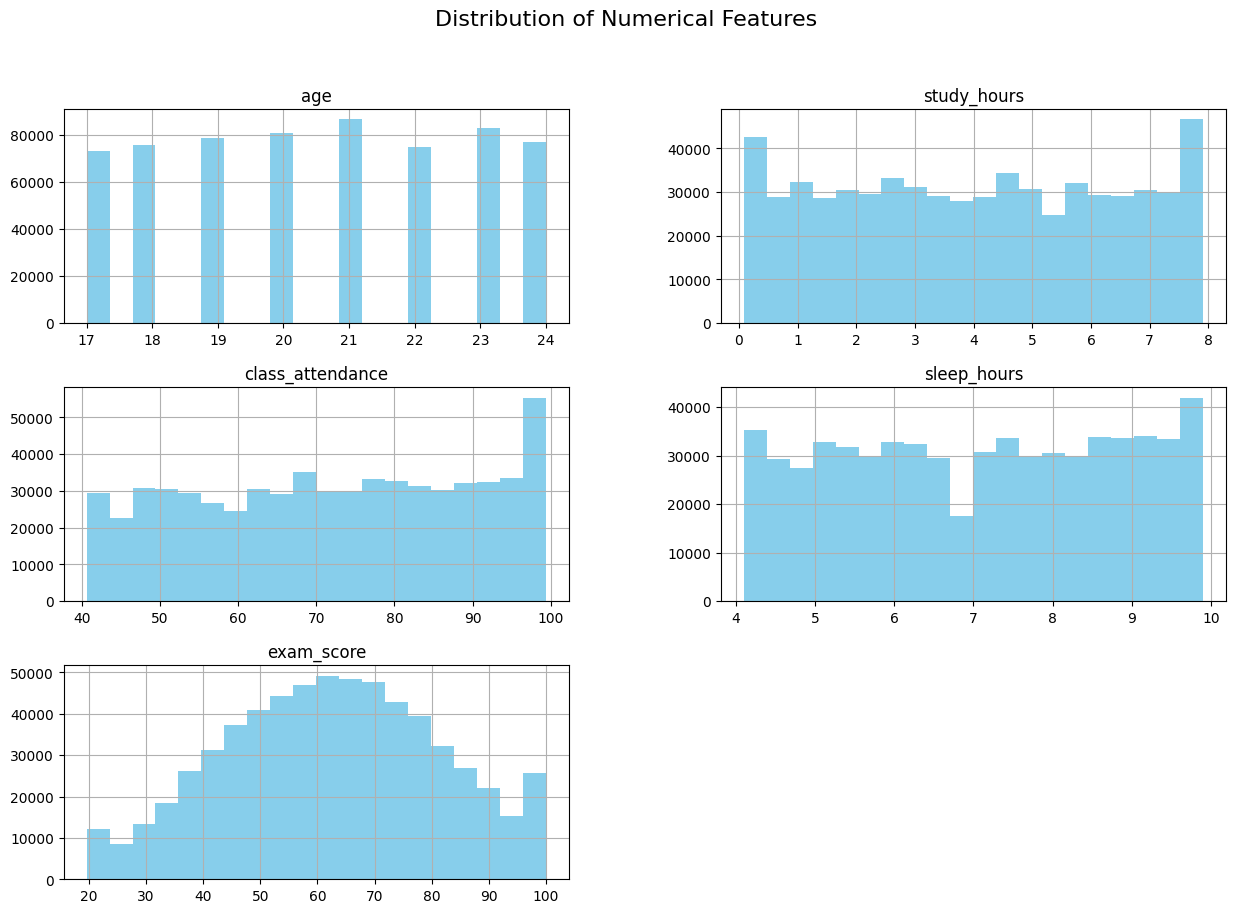

In [15]:
numerical_cols = ['age', 'study_hours', 'class_attendance', 'sleep_hours', 'exam_score']

train[numerical_cols].hist(bins=20, figsize=(15,10), color='skyblue')
plt.suptitle('Distribution of Numerical Features', fontsize=16)
plt.show()

In [16]:
train[["class_attendance","exam_score"]].corr()


,class_attendance,exam_score
class_attendance,1.000000,0.360954
exam_score,0.360954,1.000000


In [17]:
train[["study_hours","exam_score"]].corr()


,study_hours,exam_score
study_hours,1.000000,0.762267
exam_score,0.762267,1.000000


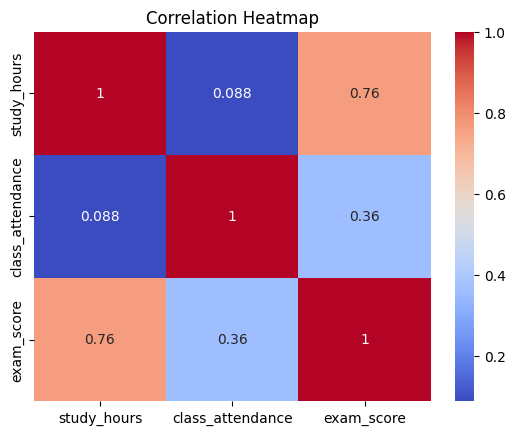

In [18]:
sns.heatmap(train[["study_hours","class_attendance","exam_score"]].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [19]:
train.groupby("gender")["exam_score"].mean()

gender
female    62.563220
male      62.175561
other     62.781191
Name: exam_score, dtype: float64

In [20]:
train.groupby("internet_access")["exam_score"].mean()

internet_access
no     62.478038
yes    62.509172
Name: exam_score, dtype: float64

In [21]:
train.groupby("study_method")["exam_score"].mean()

study_method
coaching         69.266665
group study      60.531838
mixed            65.101735
online videos    59.727607
self-study       57.700155
Name: exam_score, dtype: float64

In [22]:
train.groupby("exam_difficulty")["exam_score"].mean()

exam_difficulty
easy        62.214401
hard        62.671693
moderate    62.606060
Name: exam_score, dtype: float64

In [23]:
train.groupby("facility_rating")["exam_score"].mean()

facility_rating
high      66.707126
low       57.954546
medium    63.028954
Name: exam_score, dtype: float64

In [24]:
train.groupby("sleep_quality")["exam_score"].mean()

sleep_quality
average    62.662000
good       67.884885
poor       56.995470
Name: exam_score, dtype: float64

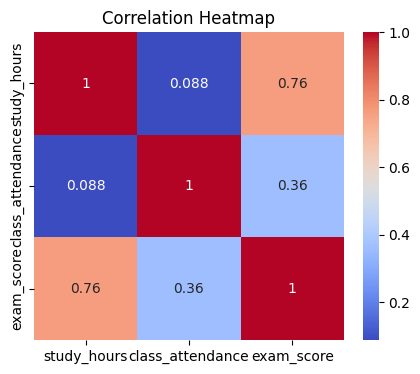

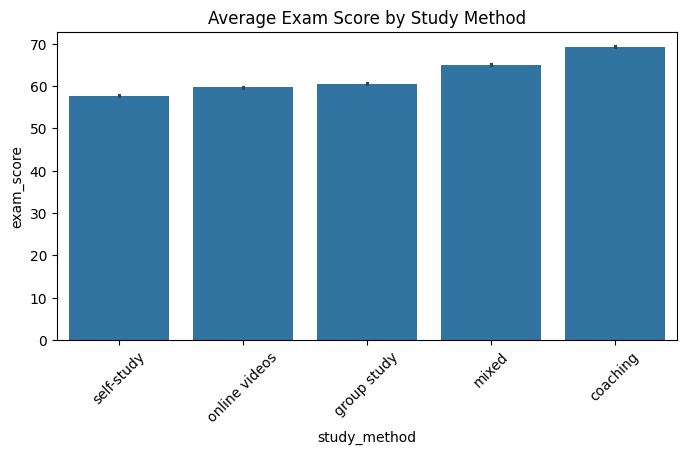

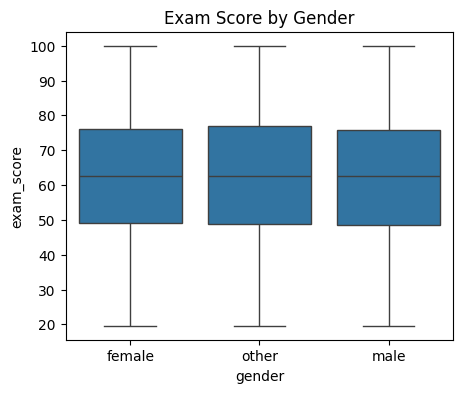

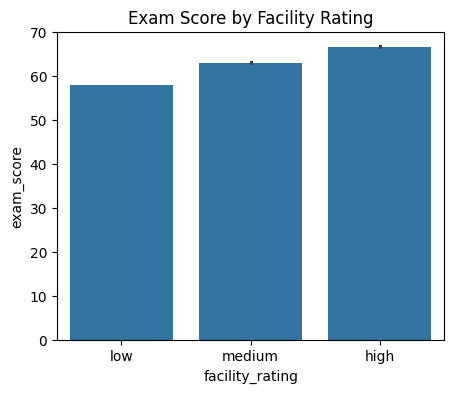

In [25]:




#Correlation heatmap (numerical variables)
plt.figure(figsize=(5,4))
sns.heatmap(train[["study_hours","class_attendance","exam_score"]].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


# Exam Score by Study Method
plt.figure(figsize=(8,4))
sns.barplot(x="study_method", y="exam_score", data=train,
            order=["self-study","online videos","group study","mixed","coaching"])
plt.xticks(rotation=45)
plt.title("Average Exam Score by Study Method")
plt.show()



#  Exam Score by Gender
plt.figure(figsize=(5,4))
sns.boxplot(x="gender", y="exam_score", data=train)
plt.title("Exam Score by Gender")
plt.show()

#  Exam Score by Facility Rating
plt.figure(figsize=(5,4))
sns.barplot(x="facility_rating", y="exam_score", data=train,
            order=["low","medium","high"])
plt.title("Exam Score by Facility Rating")
plt.show()

In [27]:
X = train.drop(columns=['id','exam_score'])  # all columns except the target
y = train['exam_score']                 # target column

In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [29]:
categorical_cols = ["gender", "course", "internet_access",
                    "sleep_quality", "study_method", "facility_rating", "exam_difficulty"]

numerical_cols = ["age", "study_hours","class_attendance", "sleep_hours"]

In [30]:
X_train = pd.get_dummies(X_train, columns=categorical_cols)

In [31]:
X_train


,age,study_hours,class_attendance,sleep_hours,gender_female,gender_male,gender_other,course_b.com,course_b.sc,course_b.tech,...,study_method_group study,study_method_mixed,study_method_online videos,study_method_self-study,facility_rating_high,facility_rating_low,facility_rating_medium,exam_difficulty_easy,exam_difficulty_hard,exam_difficulty_moderate
625149,20,0.84,79.0,9.9,False,False,True,True,False,False,...,False,True,False,False,False,True,False,False,True,False
276435,19,3.35,94.2,6.0,True,False,False,True,False,False,...,True,False,False,False,False,False,True,False,False,True
43949,18,2.20,87.5,6.8,True,False,False,False,False,False,...,False,False,True,False,True,False,False,True,False,False
280523,18,3.10,64.0,7.6,False,True,False,False,False,False,...,False,False,False,True,False,False,True,False,False,True
619977,22,1.44,56.2,5.5,True,False,False,False,False,False,...,False,False,True,False,False,False,True,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
110268,21,2.88,93.4,6.1,False,True,False,False,False,False,...,False,False,False,True,False,True,False,False,False,True
259178,20,6.90,74.5,4.3,False,True,False,False,False,False,...,False,False,True,False,False,False,True,False,False,True
365838,20,1.54,59.3,8.4,False,False,True,True,False,False,...,False,True,False,False,False,True,False,False,True,False
131932,20,6.30,88.4,6.2,False,False,True,False,False,True,...,True,False,False,False,False,True,False,False,False,True


In [32]:
X_train.columns

Index(['age', 'study_hours', 'class_attendance', 'sleep_hours',
       'gender_female', 'gender_male', 'gender_other', 'course_b.com',
       'course_b.sc', 'course_b.tech', 'course_ba', 'course_bba', 'course_bca',
       'course_diploma', 'internet_access_no', 'internet_access_yes',
       'sleep_quality_average', 'sleep_quality_good', 'sleep_quality_poor',
       'study_method_coaching', 'study_method_group study',
       'study_method_mixed', 'study_method_online videos',
       'study_method_self-study', 'facility_rating_high',
       'facility_rating_low', 'facility_rating_medium', 'exam_difficulty_easy',
       'exam_difficulty_hard', 'exam_difficulty_moderate'],
      dtype='object')

In [33]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [34]:
test_encoded = pd.get_dummies(X_test, columns=categorical_cols)
test_encoded = test_encoded.reindex(columns=X_train.columns, fill_value=0)

In [35]:
test_encoded

,age,study_hours,class_attendance,sleep_hours,gender_female,gender_male,gender_other,course_b.com,course_b.sc,course_b.tech,...,study_method_group study,study_method_mixed,study_method_online videos,study_method_self-study,facility_rating_high,facility_rating_low,facility_rating_medium,exam_difficulty_easy,exam_difficulty_hard,exam_difficulty_moderate
364426,18,3.07,88.3,4.1,False,False,True,False,True,False,...,False,False,False,False,False,True,False,False,True,False
224752,21,3.28,49.6,7.0,False,True,False,True,False,False,...,False,False,True,False,True,False,False,False,False,True
110423,20,4.45,42.5,6.7,True,False,False,False,False,False,...,True,False,False,False,True,False,False,False,False,True
272555,21,4.19,82.8,5.7,False,True,False,True,False,False,...,False,True,False,False,False,True,False,False,True,False
199651,21,1.31,91.2,8.5,True,False,False,True,False,False,...,False,True,False,False,False,True,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
514830,17,0.28,55.7,4.8,True,False,False,False,False,False,...,False,False,False,True,False,True,False,True,False,False
308756,18,6.92,84.0,9.2,False,False,True,False,False,False,...,False,False,False,False,True,False,False,False,True,False
608482,20,2.08,81.1,8.5,False,True,False,False,True,False,...,True,False,False,False,False,False,True,False,True,False
82568,19,4.29,61.3,5.0,False,False,True,False,True,False,...,False,False,False,False,False,True,False,False,False,True


In [36]:
y_test_pred = model.predict(test_encoded)

In [37]:
from sklearn.metrics import r2_score, mean_absolute_error

print("R² Score:", r2_score(y_test, y_test_pred))
print("Mean Absolute Error:", mean_absolute_error(y_test, y_test_pred))

R² Score: 0.7779548844943964
Mean Absolute Error: 7.093260308258193


In [38]:

import pandas as pd

importance = pd.Series(model.coef_, index=X_train.columns)
importance.sort_values(ascending=False)



study_method_coaching         5.810899
study_hours                   5.677948
sleep_quality_good            4.379334
facility_rating_high          3.612107
study_method_mixed            1.383108
sleep_hours                   1.323474
class_attendance              0.312757
gender_other                  0.172587
course_bba                    0.170019
sleep_quality_average         0.146147
course_diploma                0.140707
course_b.tech                 0.137808
facility_rating_medium        0.047174
exam_difficulty_hard          0.021099
internet_access_no            0.001812
exam_difficulty_moderate     -0.001694
internet_access_yes          -0.001812
age                          -0.012379
exam_difficulty_easy         -0.019404
gender_female                -0.028292
course_bca                   -0.047119
course_b.com                 -0.078919
course_ba                    -0.096699
gender_male                  -0.144295
course_b.sc                  -0.225795
study_method_group study 

In [39]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_val_pred_rf = rf_model.predict(test_encoded)



In [40]:
from sklearn.metrics import r2_score, mean_absolute_error
print("Random Forest R²:", r2_score(y_test, y_val_pred_rf))
print("Random Forest MAE:", mean_absolute_error(y_test, y_val_pred_rf))

Random Forest R²: 0.7678104750286033
Random Forest MAE: 7.231920585317461


In [41]:
from sklearn.ensemble import GradientBoostingRegressor

gb_model = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
gb_model.fit(X_train, y_train)

y_val_pred_gb = gb_model.predict(test_encoded)

print("Gradient Boosting R²:", r2_score(y_test, y_val_pred_gb))
print("Gradient Boosting MAE:", mean_absolute_error(y_test, y_val_pred_gb))

Gradient Boosting R²: 0.78023532510312
Gradient Boosting MAE: 7.0653798994096215


In [42]:
test_data = pd.read_csv("test.csv")
test_data_ids=test_data["id"]
test_data=test_data.drop("id",axis=1)

In [43]:
test_data_encoded = pd.get_dummies(test_data)
test_data__encoded = test_data_encoded.reindex(columns=X_train.columns, fill_value=0)

In [44]:
test_predictions = gb_model.predict(test_data__encoded)

In [45]:
submission = pd.DataFrame({
    "id": test_data_ids,
    "exam_score": test_predictions
})

In [46]:


submission.to_csv("submission.csv", index=False)

In [47]:
df=pd.read_csv("submission.csv")

In [48]:
df.head(35)

,id,exam_score
0,630000,71.888572
1,630001,70.354998
2,630002,87.126545
3,630003,54.587204
4,630004,46.997604
5,630005,72.058670
6,630006,72.985761
7,630007,59.431193
8,630008,78.370454
9,630009,90.507218
